In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.mast import Catalogs, Observations
import astropy.table as at


In [3]:
permanent_artifact_folder = '/Users/philvanlane/Documents/lightcurve_data_artifacts/'

### One time formattings to be consistent with code

In [3]:
tic = Catalogs.query_criteria(
    catalog="Tic",
    Teff=[None, 3900],
    objType="STAR"
)

KeyboardInterrupt: 

In [5]:

obs = Observations.query_criteria(
    obs_collection="TESS",
    dataproduct_type="timeseries",
    t_exptime=[120,120]
)


KeyboardInterrupt: 

In [ ]:

# 3. Join on TIC ID
tic_ids = set(tic['ID'])
obs_ids = set(obs['target_name'])

matched = tic_ids.intersection(obs_ids)


#### Normalize photometry

In [5]:
cf_phot['norm_G0'] = (cf_phot['G_0'] - np.nanmedian(cf_phot['G_0']))/np.nanstd(cf_phot['G_0'])
cf_phot['norm_G0_err'] = cf_phot['e_G_0']/np.nanstd(cf_phot['G_0'])

cf_phot['norm_BP0'] = (cf_phot['BP_0'] - np.nanmedian(cf_phot['BP_0']))/np.nanstd(cf_phot['BP_0'])
cf_phot['norm_RP0'] = (cf_phot['RP_0'] - np.nanmedian(cf_phot['RP_0']))/np.nanstd(cf_phot['RP_0'])

cf_phot['norm_BP0_err'] = cf_phot['e_BP_0']/np.nanstd(cf_phot['BP_0'])
cf_phot['norm_RP0_err'] = cf_phot['e_RP_0']/np.nanstd(cf_phot['RP_0'])

cf_phot['norm_parallax'] = (cf_phot['dr3_parallax_zpt_corrected'] - np.nanmedian(cf_phot['dr3_parallax_zpt_corrected']))/np.nanstd(cf_phot['dr3_parallax_zpt_corrected'])
cf_phot['norm_parallax_err'] = cf_phot['parallax_error']/np.nanstd(cf_phot['dr3_parallax_zpt_corrected'])

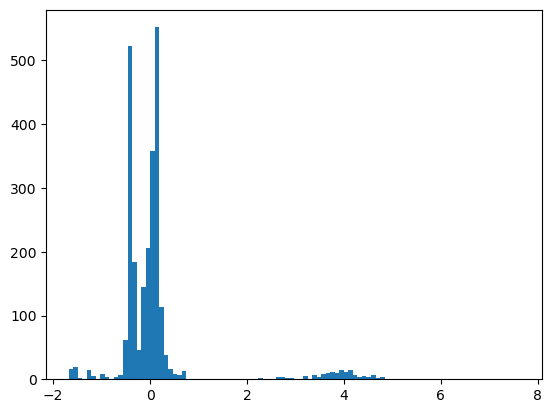

In [7]:
plt.hist(cf_phot['norm_parallax'], bins=100)
plt.show()

#### Lightcurves by star and sector

In [48]:
# Use sample light curve and sector
sample = lc_by_sector['405461319_42']
tic = sample['TIC_ID']

# Pre-process time
time = sample['time']
sector_time = (time - time[0])

# Pre-process flux
flux = np.array(sample['flux'].data)
mask = (np.isfinite(flux) & np.isfinite(time))
flux = flux[mask]
sector_time = sector_time[mask]
flux_norm = (flux - np.nanmean(flux)) / np.nanstd(flux)

# Pre-process flux error
flux_err = np.array(sample['flux_err'].data)
med_flux_error = np.nanmedian(flux_err)
flux_err = flux_err[mask]
flux_err = np.nan_to_num(flux_err, nan=med_flux_error, posinf=med_flux_error, neginf=med_flux_error)

# Stellar parameters
stellar_params = cf_phot.loc[cf_phot['TIC_ID'] == tic]
norm_G0 = stellar_params.norm_G0.values[0]
norm_G0_err = stellar_params.norm_G0_err.values[0]
norm_BP0 = stellar_params.norm_BP0.values[0]
norm_BP0_err = stellar_params.norm_BP0_err.values[0]
norm_RP0 = stellar_params.norm_RP0.values[0]
norm_RP0_err = stellar_params.norm_RP0_err.values[0]
norm_parallax = stellar_params.norm_parallax.values[0]
norm_parallax_err = stellar_params.norm_parallax_err.values[0]


# Metadata
metadata = {
    'tic': sample['TIC_ID'],
    'sector': sample['sector'],
    'duration': sector_time[-1] - sector_time[0],
    'med_flux_error': med_flux_error,
    'n_points': len(flux),
    'mean_flux': np.mean(flux),
    'std_flux': np.std(flux),
    'norm_G0': norm_G0,
    'norm_G0_err': norm_G0_err,
    'norm_BP0': norm_BP0,
    'norm_BP0_err': norm_BP0_err,
    'norm_RP0': norm_RP0,
    'norm_RP0_err': norm_RP0_err,
    'norm_parallax': norm_parallax,
    'norm_parallax_err': norm_parallax_err
}

In [103]:
times = []
fluxes = []
flux_errs = []
metadatas = []
frequencies = []
powers = []
f_stats = []
acfs = []

for i,k in enumerate(lc_by_sector.keys()):
    if i % 100 == 0:
        print(f"Processing light curve {i}")
    # Use sample light curve and sector
    sample = lc_by_sector[k]
    tic = sample['TIC_ID']
    stellar_params = cf_phot.loc[cf_phot['TIC_ID'] == tic]
    if len(stellar_params) == 0:
        continue

    # Pre-process time
    time = sample['time']
    sector_time = (time - time[0])

    # Pre-process flux
    flux = np.array(sample['flux'].data)
    mask = (np.isfinite(flux) & np.isfinite(time))
    flux = flux[mask]
    sector_time = sector_time[mask]
    flux_norm = (flux - np.nanmean(flux)) / np.nanstd(flux)
    if np.nanmean(flux) < 0:
        continue

    # Pre-process flux error
    flux_err = np.array(sample['flux_err'].data)
    med_flux_error = np.nanmedian(flux_err)
    flux_err = flux_err[mask]
    flux_err = np.nan_to_num(flux_err, nan=med_flux_error, posinf=med_flux_error, neginf=med_flux_error)
    flux_err = flux_err / np.nanstd(flux)

    # Get stellar parameters
    norm_G0 = stellar_params.norm_G0.values[0]
    norm_G0_err = stellar_params.norm_G0_err.values[0]
    norm_BP0 = stellar_params.norm_BP0.values[0]
    norm_BP0_err = stellar_params.norm_BP0_err.values[0]
    norm_RP0 = stellar_params.norm_RP0.values[0]
    norm_RP0_err = stellar_params.norm_RP0_err.values[0]
    norm_parallax = stellar_params.norm_parallax.values[0]
    norm_parallax_err = stellar_params.norm_parallax_err.values[0]

    # Get power spectra, f_stat and acf
    freq = extra_channels[k]['freq']
    power = extra_channels[k]['power']
    f_stat = extra_channels[k]['f_stat']
    acf = extra_channels[k]['acf']

    # Metadata
    metadata = {
        'tic': sample['TIC_ID'],
        'sector': sample['sector'],
        'duration': sector_time[-1] - sector_time[0],
        'med_flux_error': med_flux_error,
        'n_points': len(flux),
        'mean_flux': np.nanmean(flux),
        'std_flux': np.nanstd(flux),
        'norm_G0': norm_G0,
        'norm_G0_err': norm_G0_err,
        'norm_BP0': norm_BP0,
        'norm_BP0_err': norm_BP0_err,
        'norm_RP0': norm_RP0,
        'norm_RP0_err': norm_RP0_err,
        'norm_parallax': norm_parallax,
        'norm_parallax_err': norm_parallax_err
    }
    times.append(sector_time)
    fluxes.append(flux_norm)
    flux_errs.append(flux_err)
    metadatas.append(metadata)
    frequencies.append(freq)
    powers.append(power)
    f_stats.append(f_stat)
    acfs.append(acf)

Processing light curve 0
Processing light curve 100
Processing light curve 200
Processing light curve 300
Processing light curve 400
Processing light curve 500
Processing light curve 600
Processing light curve 700
Processing light curve 800
Processing light curve 900
Processing light curve 1000
Processing light curve 1100
Processing light curve 1200
Processing light curve 1300
Processing light curve 1400
Processing light curve 1500
Processing light curve 1600
Processing light curve 1700
Processing light curve 1800
Processing light curve 1900
Processing light curve 2000
Processing light curve 2100
Processing light curve 2200
Processing light curve 2300
Processing light curve 2400
Processing light curve 2500
Processing light curve 2600
Processing light curve 2700
Processing light curve 2800
Processing light curve 2900
Processing light curve 3000
Processing light curve 3100
Processing light curve 3200
Processing light curve 3300
Processing light curve 3400
Processing light curve 3500
Proc

In [104]:
# Normalize mean flux across all light curves

means = []
log_means = []

# Calculate scaling
for i in range(len(metadatas)):
    mean_flux = metadatas[i]['mean_flux']
    means.append(mean_flux)
    log_means.append(np.log10(mean_flux))

mean_of_means = np.nanmean(log_means)
std_of_means = np.nanstd(log_means)

for i in range(len(metadatas)):
    metadatas[i]['norm_log_mean_flux'] = (np.log10(metadatas[i]['mean_flux']) - mean_of_means) / std_of_means

In [105]:
dict = {
    'time': times,
    'flux': fluxes,
    'flux_err': flux_errs,
    'frequencies': frequencies,
    'powers': powers,
    'f_stats': f_stats,
    'acfs': acfs,
    'metadatas': metadatas,
}
with open(f"{permanent_artifact_folder}star_sector_lc_formatted_with_extra_channels.pickle", "wb") as file:
    pickle.dump(dict, file)

#### Light curves by star and day

In [ ]:
sample = lc_by_sector['405461319_42']

# Get all days in the sample light curve
days = np.unique(np.round(sample['time'])).astype(int)

# Pre-processing
time = sample['time']
flux = np.array(sample['flux'].data)
mask = (np.isfinite(flux) & np.isfinite(time))
flux = flux[mask]
time = time[mask]

# Pre-process flux error
flux_err = np.array(sample['flux_err'].data)
flux_err = flux_err[mask]
med_flux_error = np.nanmedian(flux_err)
flux_err = np.nan_to_num(flux_err, nan=med_flux_error, posinf=med_flux_error, neginf=med_flux_error)

for d in days:
    day_mask = (np.floor(time).astype(int) == d)
    day_time = time[day_mask]
    day_time = (day_time - day_time[0])
    day_flux = flux[day_mask]
    day_flux_err = flux_err[day_mask]
    day_flux_norm = (day_flux - np.nanmean(day_flux)) / np.nanstd(day_flux)

    # Metadata
    metadata = {
        'tic': sample['TIC_ID'],
        'sector': sample['sector'],
        'day': d,
        'duration': day_time[-1] - day_time[0],
        'med_sector_flux_error': med_flux_error,
        'n_points': len(day_flux_norm),
        'mean_flux': np.mean(day_flux),
        'std_flux': np.std(day_flux),
    }

In [16]:
times = []
raw_fluxes = []
raw_flux_errs = []
fluxes = []
flux_errs = []
metadatas = []

for i,k in enumerate(lc_by_sector.keys()):
    if i % 100 == 0:
        print(f"Processing light curve {i}")
    # Use sample light curve and sector
    sample = lc_by_sector[k]

    # Pre-processing
    time = sample['time']
    flux = np.array(sample['flux'].data)
    mask = (np.isfinite(flux) & np.isfinite(time))
    flux = flux[mask]
    time = time[mask]

    # Pre-process flux error
    flux_err = np.array(sample['flux_err'].data)
    flux_err = flux_err[mask]
    med_flux_error = np.nanmedian(flux_err)
    flux_err = np.nan_to_num(flux_err, nan=med_flux_error, posinf=med_flux_error, neginf=med_flux_error)

    # Get all days in the sample light curve
    days = np.unique(np.floor(time)).astype(int)

    for d in days:
        day_mask = (np.floor(time).astype(int) == d)
        day_time = time[day_mask]
        day_time = (day_time - day_time[0])
        day_flux = flux[day_mask]
        day_flux_err = flux_err[day_mask]
        day_flux_norm = (day_flux - np.nanmean(day_flux)) / np.nanstd(day_flux)
        day_flux_err_norm = day_flux_err / np.nanstd(day_flux)

        # Metadata
        metadata = {
            'tic': sample['TIC_ID'],
            'sector': sample['sector'],
            'day': d,
            'duration': day_time[-1] - day_time[0],
            'med_sector_flux_error': med_flux_error,
            'n_points': len(day_flux_norm),
            'mean_flux': np.mean(day_flux),
            'std_flux': np.std(day_flux),
        }
        times.append(day_time)
        fluxes.append(day_flux_norm)
        raw_fluxes.append(day_flux)
        raw_flux_errs.append(day_flux_err)
        flux_errs.append(day_flux_err)
        metadatas.append(metadata)

Processing light curve 0
Processing light curve 100


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_46784/471571397.py:36: RuntimeWarning: invalid value encountered in divide
  day_flux_norm = (day_flux - np.nanmean(day_flux)) / np.nanstd(day_flux)
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_46784/471571397.py:37: RuntimeWarning: divide by zero encountered in divide
  day_flux_err_norm = day_flux_err / np.nanstd(day_flux)


Processing light curve 200
Processing light curve 300
Processing light curve 400
Processing light curve 500
Processing light curve 600
Processing light curve 700
Processing light curve 800
Processing light curve 900
Processing light curve 1000
Processing light curve 1100
Processing light curve 1200
Processing light curve 1300


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_46784/471571397.py:36: RuntimeWarning: invalid value encountered in divide
  day_flux_norm = (day_flux - np.nanmean(day_flux)) / np.nanstd(day_flux)
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_46784/471571397.py:37: RuntimeWarning: divide by zero encountered in divide
  day_flux_err_norm = day_flux_err / np.nanstd(day_flux)


Processing light curve 1400
Processing light curve 1500
Processing light curve 1600
Processing light curve 1700
Processing light curve 1800
Processing light curve 1900
Processing light curve 2000
Processing light curve 2100
Processing light curve 2200
Processing light curve 2300
Processing light curve 2400
Processing light curve 2500
Processing light curve 2600
Processing light curve 2700
Processing light curve 2800
Processing light curve 2900
Processing light curve 3000
Processing light curve 3100
Processing light curve 3200
Processing light curve 3300
Processing light curve 3400
Processing light curve 3500
Processing light curve 3600
Processing light curve 3700
Processing light curve 3800
Processing light curve 3900
Processing light curve 4000
Processing light curve 4100
Processing light curve 4200
Processing light curve 4300
Processing light curve 4400
Processing light curve 4500
Processing light curve 4600
Processing light curve 4700
Processing light curve 4800
Processing light cur

In [ ]:
dict = {
    'time': times,
    'flux': fluxes,
    'flux_raw': raw_fluxes,
    'flux_err': flux_errs,
    'flux_err_raw': raw_flux_errs,
    'metadatas': metadatas,
}
with open(f"{permanent_artifact_folder}star_day_lc_formatted_withraw.pickle", "wb") as file:
    pickle.dump(dict, file)